In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv('iris_data.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
df.shape

(150, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [ ]:
df.nunique()

,0
Id,150
SepalLengthCm,35
SepalWidthCm,23
PetalLengthCm,43
PetalWidthCm,22
Species,3


In [ ]:
y = df['Species']

# method 2 y= df.iloc[ : , 5:6]


In [ ]:
x=df.drop('Species',axis=1)   # method 2 x = df.iloc[ : , 1:5]
x.shape

(150, 5)

In [ ]:
print(y)

0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
145    Iris-virginica
146    Iris-virginica
147    Iris-virginica
148    Iris-virginica
149    Iris-virginica
Name: Species, Length: 150, dtype: object


In [ ]:
# random split using inbuilt method
from sklearn.model_selection import train_test_split

xtrain , xtest , ytrain , ytest = train_test_split(x,y,test_size = 0.2)

In [ ]:
##### feature the scale

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
xtrain = sc.fit_transform(xtrain)
xtest = sc.fit_transform(xtest)

In [ ]:
print(xtrain)

[[ 1.32798134e+00  1.68091462e+00 -2.59141075e-01  1.21434164e+00
   5.69280241e-01]
 [ 8.76798554e-01  1.68091462e+00  1.17610180e+00  1.37980833e+00
   1.69532907e+00]
 [ 1.54906091e-01  1.07879595e+00 -2.59141075e-01  7.73097140e-01
   6.94396777e-01]
 [ 1.14750823e+00 -2.45865123e-01 -7.37555368e-01  7.17941577e-01
   1.06974639e+00]
 [-7.02341209e-01 -8.47983793e-01  6.97687510e-01 -1.15734756e+00
  -1.18235127e+00]
 [-6.57222930e-01 -1.57052620e+00 -1.93359110e+00 -1.26765869e+00
  -1.05723473e+00]
 [ 1.62125016e+00 -5.01765558e-03 -9.76762514e-01  8.28252703e-01
   9.44629850e-01]
 [-7.06853036e-02 -5.01765558e-03 -9.76762514e-01  2.76697074e-01
  -1.81418978e-01]
 [-1.46935195e+00 -4.86712591e-01  1.89372324e+00 -1.04703644e+00
  -9.32118197e-01]
 [-8.82814324e-01 -4.86712591e-01  6.97687510e-01 -1.15734756e+00
  -9.32118197e-01]
 [-6.34663790e-01 -1.69094993e+00  2.19273217e-01 -1.26765869e+00
  -1.18235127e+00]
 [ 5.60970601e-01 -1.25441389e-01 -2.59141075e-01  3.31852637e-01

In [ ]:
# build the model
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors = 5)     # k is generally sqrt(count)/2
model.fit(xtrain, ytrain)

KNeighborsClassifier()

In [ ]:
ypred = model.predict(xtest)
ypred


array(['Iris-versicolor', 'Iris-versicolor', 'Iris-virginica',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-virginica', 'Iris-versicolor', 'Iris-virginica',
       'Iris-setosa', 'Iris-virginica', 'Iris-versicolor', 'Iris-setosa',
       'Iris-setosa', 'Iris-virginica', 'Iris-versicolor', 'Iris-setosa',
       'Iris-virginica', 'Iris-versicolor', 'Iris-virginica',
       'Iris-versicolor', 'Iris-virginica', 'Iris-setosa',
       'Iris-virginica', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-setosa', 'Iris-versicolor', 'Iris-virginica',
       'Iris-versicolor'], dtype=object)

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(ytest,ypred)
cm

array([[ 3,  0,  0],
       [ 3, 12,  0],
       [ 0,  2, 10]])

<Axes: >

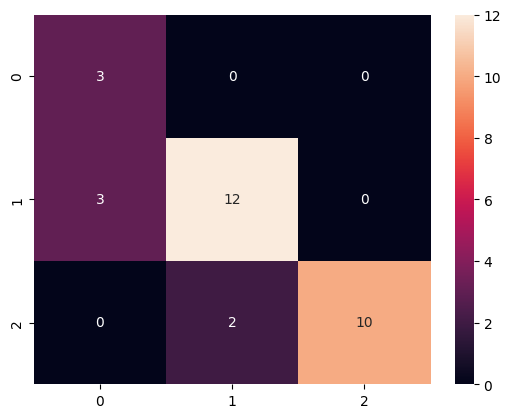

In [ ]:
import seaborn as sns
sns.heatmap(cm,annot= True)

In [ ]:
from sklearn.metrics import accuracy_score
accu = accuracy_score(ytest , ypred)
accu

0.8333333333333334

In [ ]:
print(x)

      Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0      1            5.1           3.5            1.4           0.2
1      2            4.9           3.0            1.4           0.2
2      3            4.7           3.2            1.3           0.2
3      4            4.6           3.1            1.5           0.2
4      5            5.0           3.6            1.4           0.2
..   ...            ...           ...            ...           ...
145  146            6.7           3.0            5.2           2.3
146  147            6.3           2.5            5.0           1.9
147  148            6.5           3.0            5.2           2.0
148  149            6.2           3.4            5.4           2.3
149  150            5.9           3.0            5.1           1.8

[150 rows x 5 columns]
